In [7]:
import torch
import matplotlib.pyplot as plt 
from PIL import Image
from torch import nn
from torchvision.models import resnet50
import torchvision.transforms as T
import requests
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [28]:
class DETRdemo(nn.Module):
    def __init__(self,num_classes=91,hidden_dim = 256 , nheads =8 , num_encoder_layers=6, num_decoder_layers=6):
        
        super().__init__()
        
        #resnet backbone 

        self.backbone = resnet50()
        del self.backbone.fc
        self.conv = nn.Conv2d(2048,hidden_dim, 1)

        # transfomer encoder + decoder
        
        self.transformer = nn.Transformer(hidden_dim , nheads , num_encoder_layers , num_decoder_layers)
        
        # MLP for class and MLP for bbox
        
        self.linear_class = nn.Linear(hidden_dim,num_classes+1)
        self.linear_bbox = nn.Linear(hidden_dim,4) 
        
        # position embedding 
        self.query_pos = nn.Parameter(torch.rand(100,hidden_dim))
        
        # position embedding for image features 
        self.row_embed = nn.Parameter(torch.rand(50,hidden_dim//2))
        self.col_embed = nn.Parameter(torch.rand(50,hidden_dim//2))
        
    def forward(self,inputs):
        
        x= self.backbone.conv1(inputs)
        x= self.backbone.bn1(x)
        x= self.backbone.relu(x)
        x= self.backbone.maxpool(x)
        
        x= self.backbone.layer1(x)
        x= self.backbone.layer2(x)
        x= self.backbone.layer3(x)
        x= self.backbone.layer4(x)
        
        # projecting from 2048 to 256 dimensions
        h = self.conv(x)
        
        H,W=h.shape[-2:]
        assert H <= self.row_embed.size(0) and W <= self.col_embed.size(0), \
            "Feature map is larger than learned positional embeddings."
        pos = torch.cat([self.col_embed[:W].unsqueeze(0).repeat(H,1,1),
                         self.row_embed[:H].unsqueeze(1).repeat(1,W,1)],dim = -1).flatten(0,1).unsqueeze(1)
        
        bs = inputs.shape[0]
        src = pos.repeat(1, bs, 1) + 0.1 * h.flatten(2).permute(2,0,1)
        query = self.query_pos.unsqueeze(1).repeat(1, bs, 1)
        h = self.transformer(src, query)
        
        return {'pred_logits': self.linear_class(h).transpose(0,1),
            'pred_boxes': self.linear_bbox(h).sigmoid().transpose(0,1)}

In [29]:
detr = DETRdemo()

state_dict = torch.hub.load_state_dict_from_url(url="https://dl.fbaipublicfiles.com/detr/detr_demo-da2a99e9.pth")
detr.load_state_dict(state_dict)
detr.eval()

DETRdemo(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

In [30]:
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]



In [31]:
transform = T.Compose([T.Resize(800),
                       T.ToTensor(),
                       T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

In [32]:
def detect(image, model, transform, threshold=0.5, min_keep=1):
    img = transform(image).unsqueeze(0)
    outputs = model(img)
    
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    conf = probas.max(-1).values
    keep = conf > threshold
    
    # If nothing passes the threshold, keep top predictions so plotting still shows results.
    if keep.sum().item() < min_keep:
        topk = conf.topk(min(min_keep, conf.numel())).indices
        keep = torch.zeros_like(conf, dtype=torch.bool)
        keep[topk] = True
    
    bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], image.size)
    
    return probas[keep], bboxes_scaled

In [33]:
url = "https://imgs.search.brave.com/NkWQPwQ-WX8Hl9Uu_asnukLCxDakiB6kl5WY3lWhVQQ/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9pbWFn/ZXMucGV4ZWxzLmNv/bS9waG90b3MvMjg2/NjYyOTAvcGV4ZWxz/LXBob3RvLTI4NjY2/MjkwL2ZyZWUtcGhv/dG8tb2YtcmVsYXhl/ZC1hc2lhbi1ibGFj/ay1iZWFyLWluLW5h/dHVyYWwtaGFiaXRh/dC5qcGVnP2F1dG89/Y29tcHJlc3MmY3M9/dGlueXNyZ2ImZHBy/PTEmdz01MDA"
im = Image.open(requests.get(url, stream=True).raw)
scores , boxes = detect(im, detr,transform)

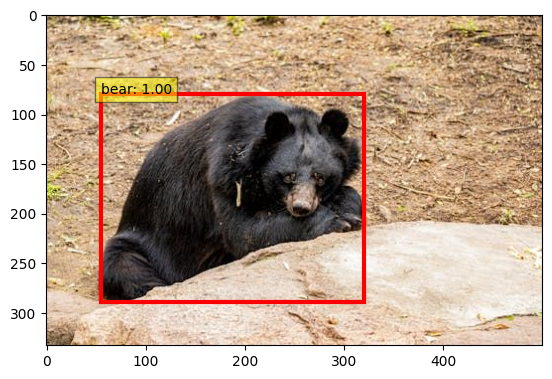

In [34]:
def plot_results(pil_img, prob, boxes):
    plt.imshow(pil_img)
    ax = plt.gca()
    for p, (xmin, ymin, xmax, ymax) in zip(prob, boxes.tolist()):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color='red', linewidth=3))
        cl = p.argmax()
        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
        ax.text(xmin, ymin, text, fontsize=10,
                bbox=dict(facecolor='yellow', alpha=0.5))
        
plot_results(im, scores, boxes)


In [36]:
print('scores shape:', scores.shape)
print('boxes shape:', boxes.shape)
print('num detections:', scores.shape[0])
if scores.numel() > 0:
    top_vals, top_idx = scores.max(-1)
    print('top 5 confidences:', top_vals[:5])
    print('top 5 class idx:', top_idx[:5])
else:
    with torch.no_grad():
        img = transform(im).unsqueeze(0)
        outputs = detr(img)
        probas_all = outputs['pred_logits'].softmax(-1)[0, :, :-1]
        top_vals_all, _ = probas_all.max(-1)
        print('max confidence over all 100 queries:', float(top_vals_all.max()))
        print('queries > 0.7:', int((top_vals_all > 0.7).sum()))
        print('queries > 0.5:', int((top_vals_all > 0.5).sum()))
        print('queries > 0.3:', int((top_vals_all > 0.3).sum()))

scores shape: torch.Size([1, 91])
boxes shape: torch.Size([1, 4])
num detections: 1
top 5 confidences: tensor([0.9999])
top 5 class idx: tensor([23])
